In [6]:
import pickle
import torch
import numpy as np
import pandas as pd
import torch.nn as nn
import dgl
from dgl.dataloading import GraphDataLoader
from torch.utils.data.sampler import SubsetRandomSampler
import sys
import os
import seaborn as sns
sys.path.append("../learning")
from utils import get_seed, get_num_params,  MultipleTensors
from args import get_args
from data_utils import get_model, get_loss_func, MIODataLoader, MIODataset
import matplotlib
import matplotlib.pyplot as plt
from tqdm import tqdm
import torch.optim as optim
import torch.nn.functional as F
from controller import venti_controler
%matplotlib inline
%config InlineBackend.figure_format = 'retina'
torch.manual_seed(0)
torch.cuda.empty_cache()

# Load Controller & Models & Data
### take scenario 1 as an example

In [ ]:
# Load models
model_paths_all = [
    "../learning/data/checkpoints/co2_all_MIOEGPT_meanvarianceuncertainty_0228_00_10_00.pt", 
    "../learning/data/checkpoints/co2_all_MIOEGPT_meanvarianceuncertainty_0228_15_25_04.pt", 
    "../learning/data/checkpoints/co2_all_MIOEGPT_meanvarianceuncertainty_0228_15_31_54.pt", 
    "../learning/data/checkpoints/co2_all_MIOEGPT_meanvarianceuncertainty_0301_16_02_36.pt",
    "../learning/data/checkpoints/co2_all_MIOEGPT_meanvarianceuncertainty_0301_16_03_28.pt", 
]
models_lst = []
device = torch.device('cuda:0')
with torch.no_grad():
    for model_path in model_paths_all:
        result = torch.load(model_path, map_location=torch.device("cuda:0"))
        args = result['args']
        model_dict = result['model']
        model = get_model(args,)
        model.load_state_dict(model_dict)
        model.eval()
        args = result['args']
        models_lst.append(model.to(device))
# Load datas
train_path = "../learning/dataset/train_data_norm.pkl"
dataset_name = "co2"
train_dataset = MIODataset(train_path, name=dataset_name, train=True, train_num=args.train_num, sort_data=args.sort_data, normalize_y=args.use_normalizer,normalize_x=args.normalize_x)
train_loader = MIODataLoader(train_dataset, batch_size=1, drop_last=False)
test_path = 'optimization_data/control_-1.pkl' # scenario: 1
test_dataset = MIODataset(test_path, name=dataset_name, train=False, test_num=args.test_num,
                            sort_data=args.sort_data,
                            normalize_y=args.use_normalizer,
                            normalize_x=args.normalize_x, y_normalizer=train_dataset.y_normalizer,
                            x_normalizer=train_dataset.x_normalizer, up_normalizer=train_dataset.up_normalizer)
test_loader = MIODataLoader(test_dataset, batch_size=1, shuffle=False, drop_last=False)
g, u_p, f = list(iter(test_loader))[0]
controller = venti_controler(models_lst, train_dataset, g, u_p, f, device)

Using Linear Attention
Using Linear Attention
Using Linear Attention
Load dataset finished 0.8212060928344727
Training with 3893 samples
Target features are normalized using unit transformer
tensor([[619.4855, 620.2894, 621.0497, 621.8191, 622.4127, 622.9807]]) tensor([[155.6501, 155.7280, 155.7338, 155.8135, 155.9132, 155.9175]])
Target features are normalized using unit transformer
Input features are normalized using unit transformer
Load dataset finished 0.0002567768096923828
Testing with 1 samples
Target features are normalized using unit transformer
Input features are normalized using unit transformer


# Single-step Optimization

In [8]:
optimized_u = controller.solver_grad(g, u_p, f, w1=1, w2=0.12, w3=0.4, epochs=100)
optimized_u = controller.visualize_control(optimized_u)

  0%|          | 0/100 [00:00<?, ?it/s]


ValueError: too many values to unpack (expected 2)

# Multi-step Optimization

In [ ]:
occupants = np.array([75] * 18 + [30] * 18 + [60] * 12 + [40] * 12 + [70] * 12)
energys = []
co2s = []
controls = [] # record all optimized control solutions
g, u_p, f = list(iter(test_loader))[0]
g = g.to(device)
data = pd.read_pickle("optimization_data/unsteady_-1.pkl")
co2_data = data["co2-ppmz-stand"]
co2_data = (np.array(co2_data[:12]).T - 400.)/400. 
co2_data = co2_data[np.newaxis, :]
co2 = []
past_co2 = MultipleTensors([torch.from_numpy(co2_data).float()])
past_co2 = past_co2.to(device)
energy = [0.5] * 12 # because scenario 1 using 12 step for baseline control
co2_high = []
for i in range(10):
    torch.cuda.empty_cache()
    current_t = 12 + i * 6
    occupant = occupants[current_t-12:current_t]
    future_occupant = occupants[current_t:current_t+6]
    print(f"{i}-th step future occupant {future_occupant}")
    with torch.no_grad():
        n_p = torch.ones(1, 13) * future_occupant[-1]
        n_p = controller.up_normalizer.transform(n_p.to(device), inverse=False)
        u_p[0,0] = n_p[0,0]
        u_p = u_p.to(device)
    x_grad = controller.solver_grad(g, u_p, past_co2, w1=1, w2=0.12, w3=0.4,  epochs=30)
    # next round
    new_past_co2 = torch.ones(1, 7492, 12)
    new_past_co2[:,:,:6] = past_co2[0].cpu()[:,:,-6:]
    with torch.no_grad():
        raw = controller.get_raw(x_grad)
        energy += [raw[0, 1::2].sum() / 3.24 / 6] * 6
        controls.append(raw)
        mu, std = controller.get_prediction(g, x_grad, past_co2)
        predict_co2 = controller.y_normalizer.transform(mu)
        predict_co2 = (predict_co2 - 400. ) / 400. # we norm the data for input
        predict_co2 = predict_co2.detach().cpu().unsqueeze(0)
        new_past_co2[:,:,6:] = predict_co2
        u_p = x_grad.detach().cpu()
        past_co2 = MultipleTensors([new_past_co2]).to(device)
        co2.append(new_past_co2[:,:,6:].detach().squeeze().numpy())
    del x_grad, mu, std, n_p 
    torch.cuda.empty_cache()
energys.append(energy)

NameError: name 'np' is not defined

# Visualize results
Note 1.   
We use np.quantile(data, 0.99) to measure the peak data.

Note 2.   
Below data is validated by ANSYS Fluent, using the above control solutions.   

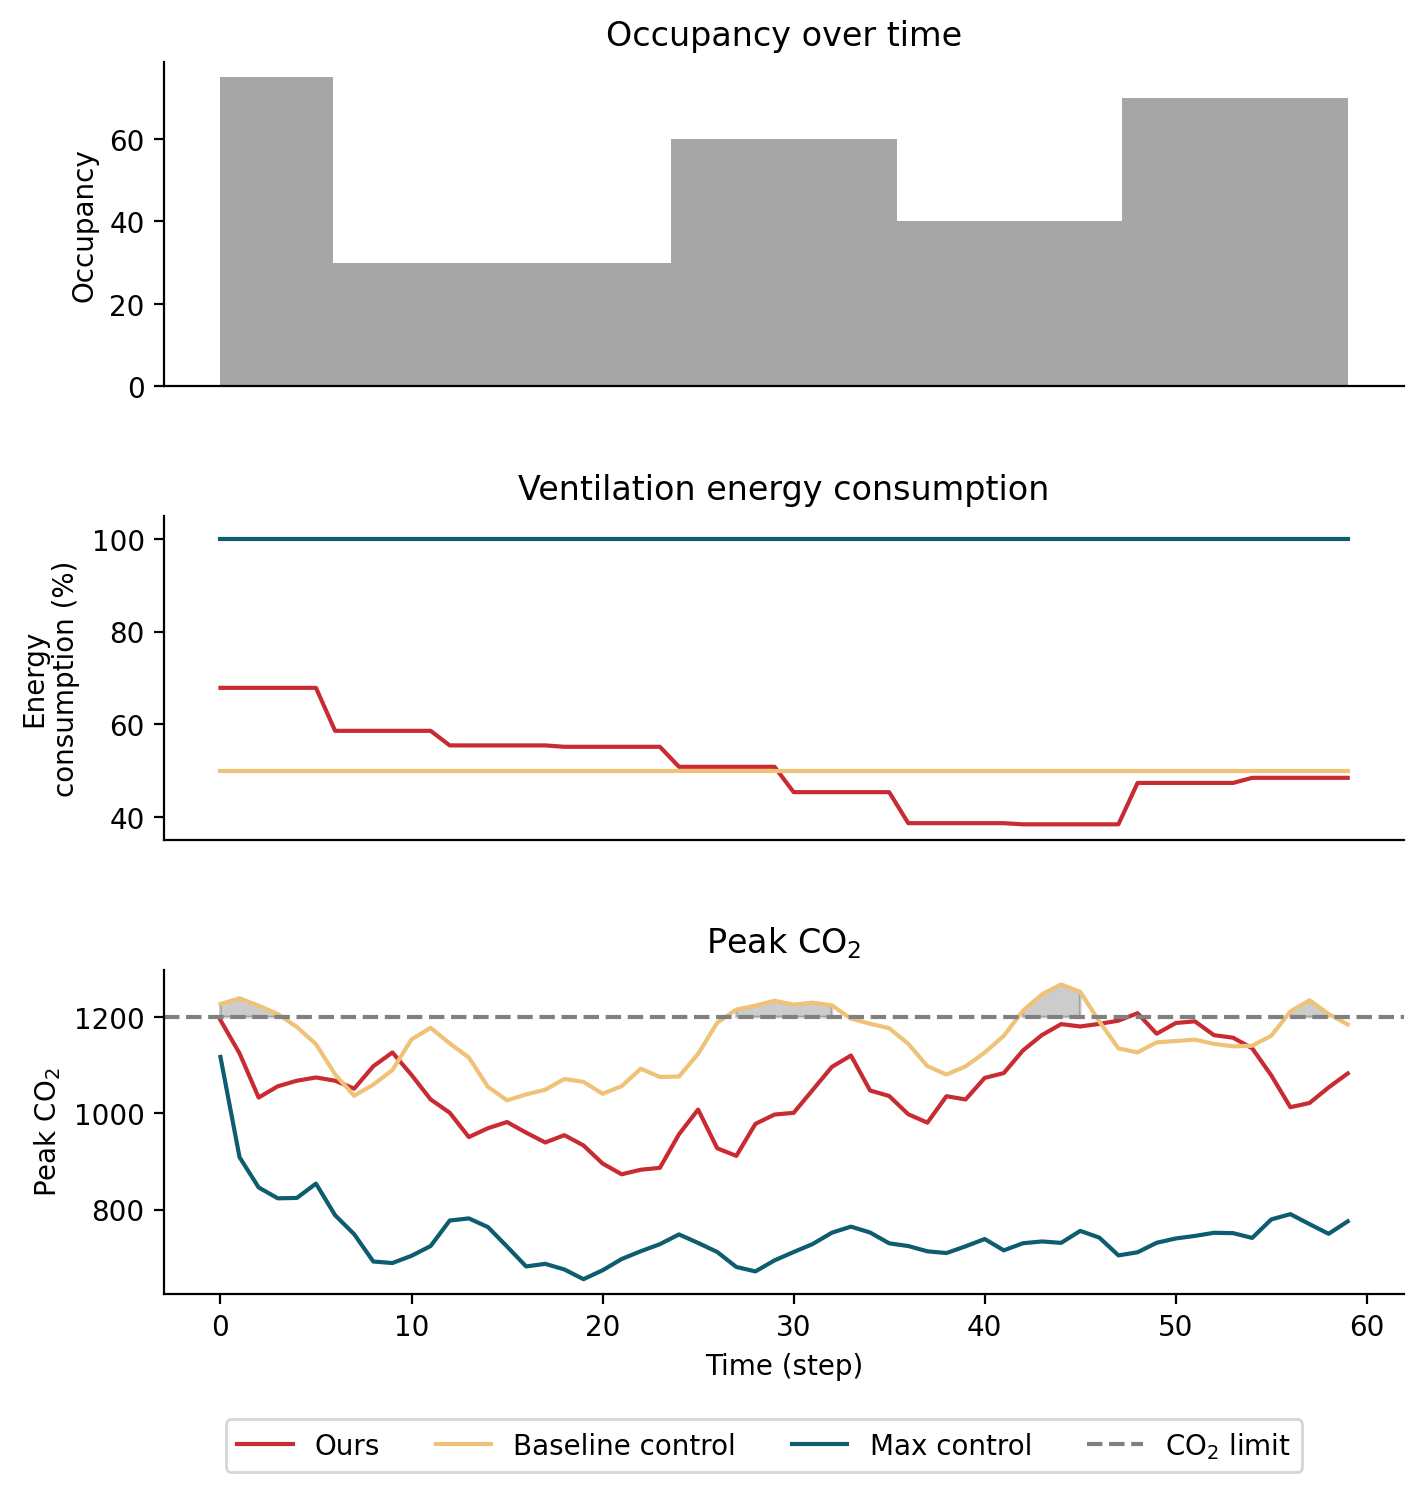

In [ ]:
# prepare the data
co2_limit = 1200
paths = ["optimization_data/unsteady_mpcoptimize.pkl", "optimization_data/unsteady_mpcbaseline.pkl", "optimization_data/unsteady_mpcmax.pkl"]
occupants = np.array([75] * 18 + [30] * 18 + [60] * 12 + [40] * 12 + [70] * 12)
co2_datas = []
energys = []
for i, p in enumerate(paths):
    data = pd.read_pickle(p)
    co2_data = np.array(data["co2-ppmz-stand"])
    co2_datas.append(co2_data)
    energy = np.repeat(data["u"][:,1::2].sum(axis=1) / 3.24 / 6 * 100, 6)
    energys.append(energy)
time = np.arange(60)
# plot
colors = [ "#c92b32","#efc278", "#0d5c70"]
methods = ["Ours", "Baseline control", "Max control"]
fig, ax = plt.subplots(3,1, figsize=(8,8))
ylabels = ["Occupancy", "Energy\nconsumption (%)", r"Peak CO$_2$"]
# occupancy 
ax[0].bar(np.arange(60), occupants[12:], color="gray", width=1, alpha=0.7)
ax[0].set_title("Occupancy over time")
# energy and co2
for i in range(3):
    ax[1].plot(energys[i], color=colors[i], label=methods[i])
    ax[1].set_ylim(35, 105)
    ax[1].set_title("Ventilation energy consumption")
    ax[2].plot(np.quantile(co2_datas[i], 0.99, axis=1), color=colors[i], label=methods[i])
    ax[2].set_title(r"Peak CO$_2$")
ax[2].axhline(co2_limit, color='gray', linestyle='--', label='CO$_2$ limit')
co2_baseline = np.quantile(co2_datas[1], 0.99, axis=1)
violation_mask = co2_baseline > co2_limit
ax[2].fill_between(time, co2_limit, co2_baseline, where=violation_mask, color='black', alpha=0.2)
ax[2].set_xlabel("Time (step)")
# Shared legend below all subplots
handles, labels = ax[2].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', ncol=4, bbox_to_anchor=(0.5, -0.01))
for i in range(3):
    ax[i].set_ylabel(ylabels[i])
    if i != 2: ax[i].set_xticks([])
    ax[i].spines['right'].set_visible(False)
    ax[i].spines['top'].set_visible(False)
#plt.tight_layout()
plt.subplots_adjust(hspace=0.4)
plt.show()